<a href="https://colab.research.google.com/github/sgulyano/CMKL41-685/blob/main/Fine-Tuning_a_Vision_Transformer_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMKL41-685 Computer Vision Lab

CMKL University

By Sarun Gulyanon

### Goal

Introduce students to fine-tuning a pretrained Vision Transformer (ViT) for image classification on a real-world, fine-grained dataset.

### Outline

In this lab, students will fine-tune a ViT-Base model, pretrained on ImageNet, to classify pet images from the Oxford-IIIT Pet Dataset into 37 breed categories. Students will explore the dataset, apply image preprocessing consistent with the ViT's pretraining statistics, freeze early transformer layers to reduce overfitting on a relatively small dataset, and train the classification head using a cosine learning-rate schedule with warmup. The notebook compares model predictions before and after fine-tuning and evaluates the final model with a confusion matrix.

### References
1. Oxford-IIIT Pet Dataset: https://www.robots.ox.ac.uk/~vgg/data/pets/
2. Dosovitskiy, A., et al. "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." ICLR, 2021.
3. google/vit-base-patch16-224 (Hugging Face Model Hub): https://huggingface.co/google/vit-base-patch16-224
4. Adapted from Transformers-for-Vision (VizuaraAI): https://github.com/VizuaraAI/Transformers-for-vision-BOOK

---

## 0. Setup and Imports

The code below imports all libraries required for dataset handling, model fine-tuning, training, and evaluation. In addition to PyTorch and TorchVision, we rely on Hugging Face’s transformers library to load a pretrained Vision Transformer.

In [ ]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import get_cosine_schedule_with_warmup

from torchmetrics.classification import MulticlassAccuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

These hyperparameters define the classification task and training configuration. The number of classes is set to 37, corresponding to the number of pet breeds in the dataset.

## 1. Exploring the Oxford-IIIT Pet Dataset

The Oxford-IIIT Pet Dataset consists of 7,349 images of cats and dogs across 37 fine-grained breed classes. Images vary in resolution but are typically larger than 200×200 pixels and contain rich texture, shape, and spatial cues. Each image is labeled with a single breed, making this a multiclass classification problem.

Although the dataset images are already reasonably high-resolution, pretrained Vision Transformers expect inputs of size 224×224, so we standardize all images to this resolution during preprocessing.

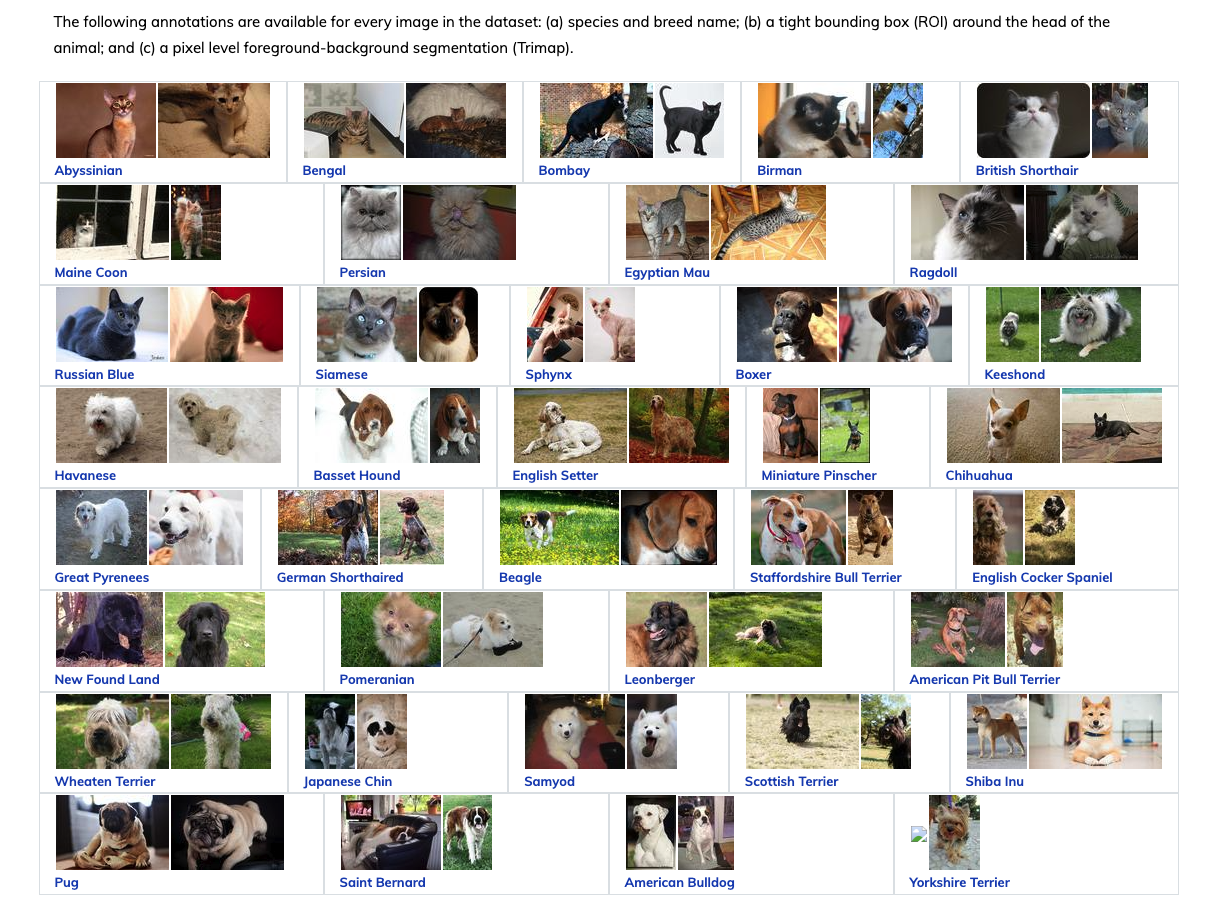

Before training, it is useful to inspect the dataset and understand the nature of the images and labels.

The code below loads the dataset without preprocessing so we can inspect its structure and class labels.

In [ ]:
raw_train = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

class_names = raw_train.classes
print(len(class_names))
print(class_names[:10])

100%|██████████| 792M/792M [00:25<00:00, 31.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.3MB/s]


37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']


This confirms that the task is a 37-way fine-grained classification problem.

The code below displays a small grid of pet images to highlight the dataset’s visual diversity and resolution.

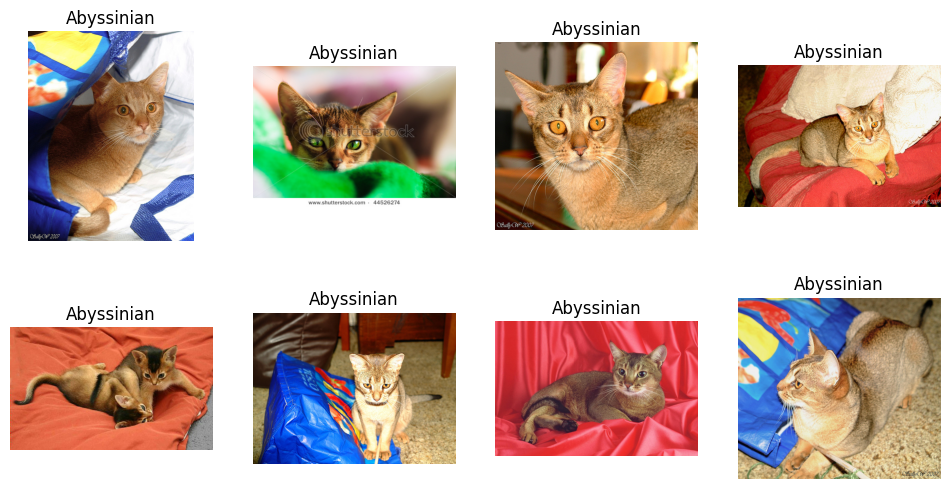

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(8):
    img, label = raw_train[i]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.show()


From this visualization we observe that images contain rich textures, variable poses, and complex backgrounds. These properties make long-range attention over image patches particularly valuable.

## 2. Image Preprocessing Aligned with ViT

Pretrained Vision Transformers rely on specific normalization statistics derived from ImageNet. To remain consistent with pretraining, we reuse the same image preprocessing pipeline.

The image processor provides the mean and standard deviation used during the original ViT training.

In [ ]:
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
print(processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [ ]:
image_mean = processor.image_mean
image_std = processor.image_std

During training we apply random cropping and horizontal flipping to improve generalization. During validation we apply deterministic resizing and center cropping.

In [ ]:
IMAGE_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE = 32
EPOCHS = 50

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std)
])

val_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std)
])


After preprocessing, every image has shape


```
(3,224,224),
```
which matches the ViT input specification.

We now construct the training and validation datasets and wrap them in PyTorch DataLoaders.

In [ ]:
train_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transforms
)

val_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 3. Model Architecture

We now load a pretrained Vision Transformer and adapt its classification head to the pet-breed classification task.

In [ ]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The model consists of a patch embedding layer, 12 transformer encoder blocks, and a classification head that maps a 768-dimensional class token to 37 output logits.

In [ ]:
print(model)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

To reduce overfitting and stabilize training on a relatively small dataset, we freeze the earliest encoder layers and fine-tune only the higher layers and classification head.

In [ ]:
for param in model.parameters():
    param.requires_grad = False

frozen_layers = []
trainable_layers = []

for name, param in model.named_parameters():
    if "classifier" in name:
        param.requires_grad = True

    if param.requires_grad:
        trainable_layers.append(name)
    else:
        frozen_layers.append(name)

print(f"Total Frozen Layers: {len(frozen_layers)}")
print(f"Total Trainable Layers: {len(trainable_layers)}")

print("\n--- Verification: Examples of Trainable Layers ---")

for p in trainable_layers:
    print(p)

Total Frozen Layers: 198
Total Trainable Layers: 2

--- Verification: Examples of Trainable Layers ---
classifier.weight
classifier.bias


In [ ]:
def print_model_parameters(model):
    trainable_params = 0
    frozen_params = 0
    all_param = 0

    for _, param in model.named_parameters():
        num_params = param.numel()
        all_param += num_params

        if param.requires_grad:
            trainable_params += num_params
        else:
            frozen_params += num_params

    print(f"trainable params: {trainable_params:,}")
    print(f"frozen params:    {frozen_params:,}")
    print(f"all params:       {all_param:,}")
    print(f"trainable%:       {100 * trainable_params / all_param:.2f}%")

# Run the function
print_model_parameters(model)

trainable params: 28,453
frozen params:    85,798,656
all params:       85,827,109
trainable%:       0.03%


## 4. Inference Before Fine-Tuning

Before training, the model’s predictions are largely unreliable for this dataset.

The code below evaluates the pretrained Vision Transformer on a validation image before any task-specific training, allowing us to observe the effect of domain mismatch.

In [ ]:
model.eval()

image, label = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(pixel_values=image)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1).item()
    confidence = probs.max(dim=1).values.item()

print(
    f"[Pre-training inference]\n"
    f"  Ground truth class : {class_names[label]}\n"
    f"  Predicted class    : {class_names[pred]}\n"
    f"  Prediction confidence : {confidence:.2f}"
)

[Pre-training inference]
  Ground truth class : Abyssinian
  Predicted class    : Shiba Inu
  Prediction confidence : 0.05


Before fine-tuning, the Vision Transformer has only seen ImageNet data during pretraining. While ImageNet contains a broad set of objects, it does not specialize in fine-grained pet-breed classification. As a result, the model often produces incorrect predictions with low confidence when evaluated directly on the Oxford-IIIT Pet dataset. The low confidence score indicates that the model is uncertain, reflecting a clear domain mismatch rather than random failure. Fine-tuning aligns the pretrained visual representations with the target task, allowing the classifier head and deeper transformer layers to adapt to subtle breed-level differences.

## 5. Training Setup

We now define the optimizer, learning-rate schedule, loss function, and evaluation metric.

In [ ]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()
accuracy = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)

## 6. Training and Validation Loop

The training loop alternates between gradient updates on the training set and accuracy evaluation on the validation set.

In [ ]:
train_losses, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(pixel_values=imgs)
        loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    accuracy.reset()
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(pixel_values=imgs).logits.argmax(dim=1)
            accuracy.update(preds, labels)

    val_accuracies.append(accuracy.compute().item())

    print(f"Epoch {epoch+1}: "
          f"Loss={train_losses[-1]:.4f}, "
          f"Val Acc={val_accuracies[-1]:.4f}")

  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 1: Loss=3.4722, Val Acc=0.2969


  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 2: Loss=2.4690, Val Acc=0.8145


  0%|          | 0/115 [00:00<?, ?it/s]

...

Epoch 48: Loss=0.1726, Val Acc=0.9373


  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 49: Loss=0.1783, Val Acc=0.9373


  0%|          | 0/115 [00:00<?, ?it/s]

Epoch 50: Loss=0.1592, Val Acc=0.9373


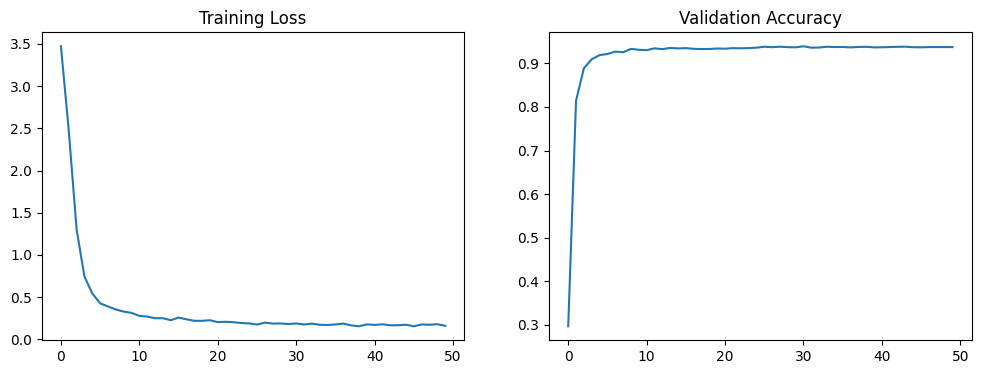

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.show()

## 7. Inference After Fine-Tuning

In [ ]:
model.eval()

image, label = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(pixel_values=image).logits
    pred = logits.argmax(dim=1).item()

print("After training → Pred:", class_names[pred],
      "| GT:", class_names[label])

After training → Pred: Abyssinian | GT: Abyssinian


After fine-tuning, predictions typically align with the ground-truth breed label.

## 8. Final Evaluation

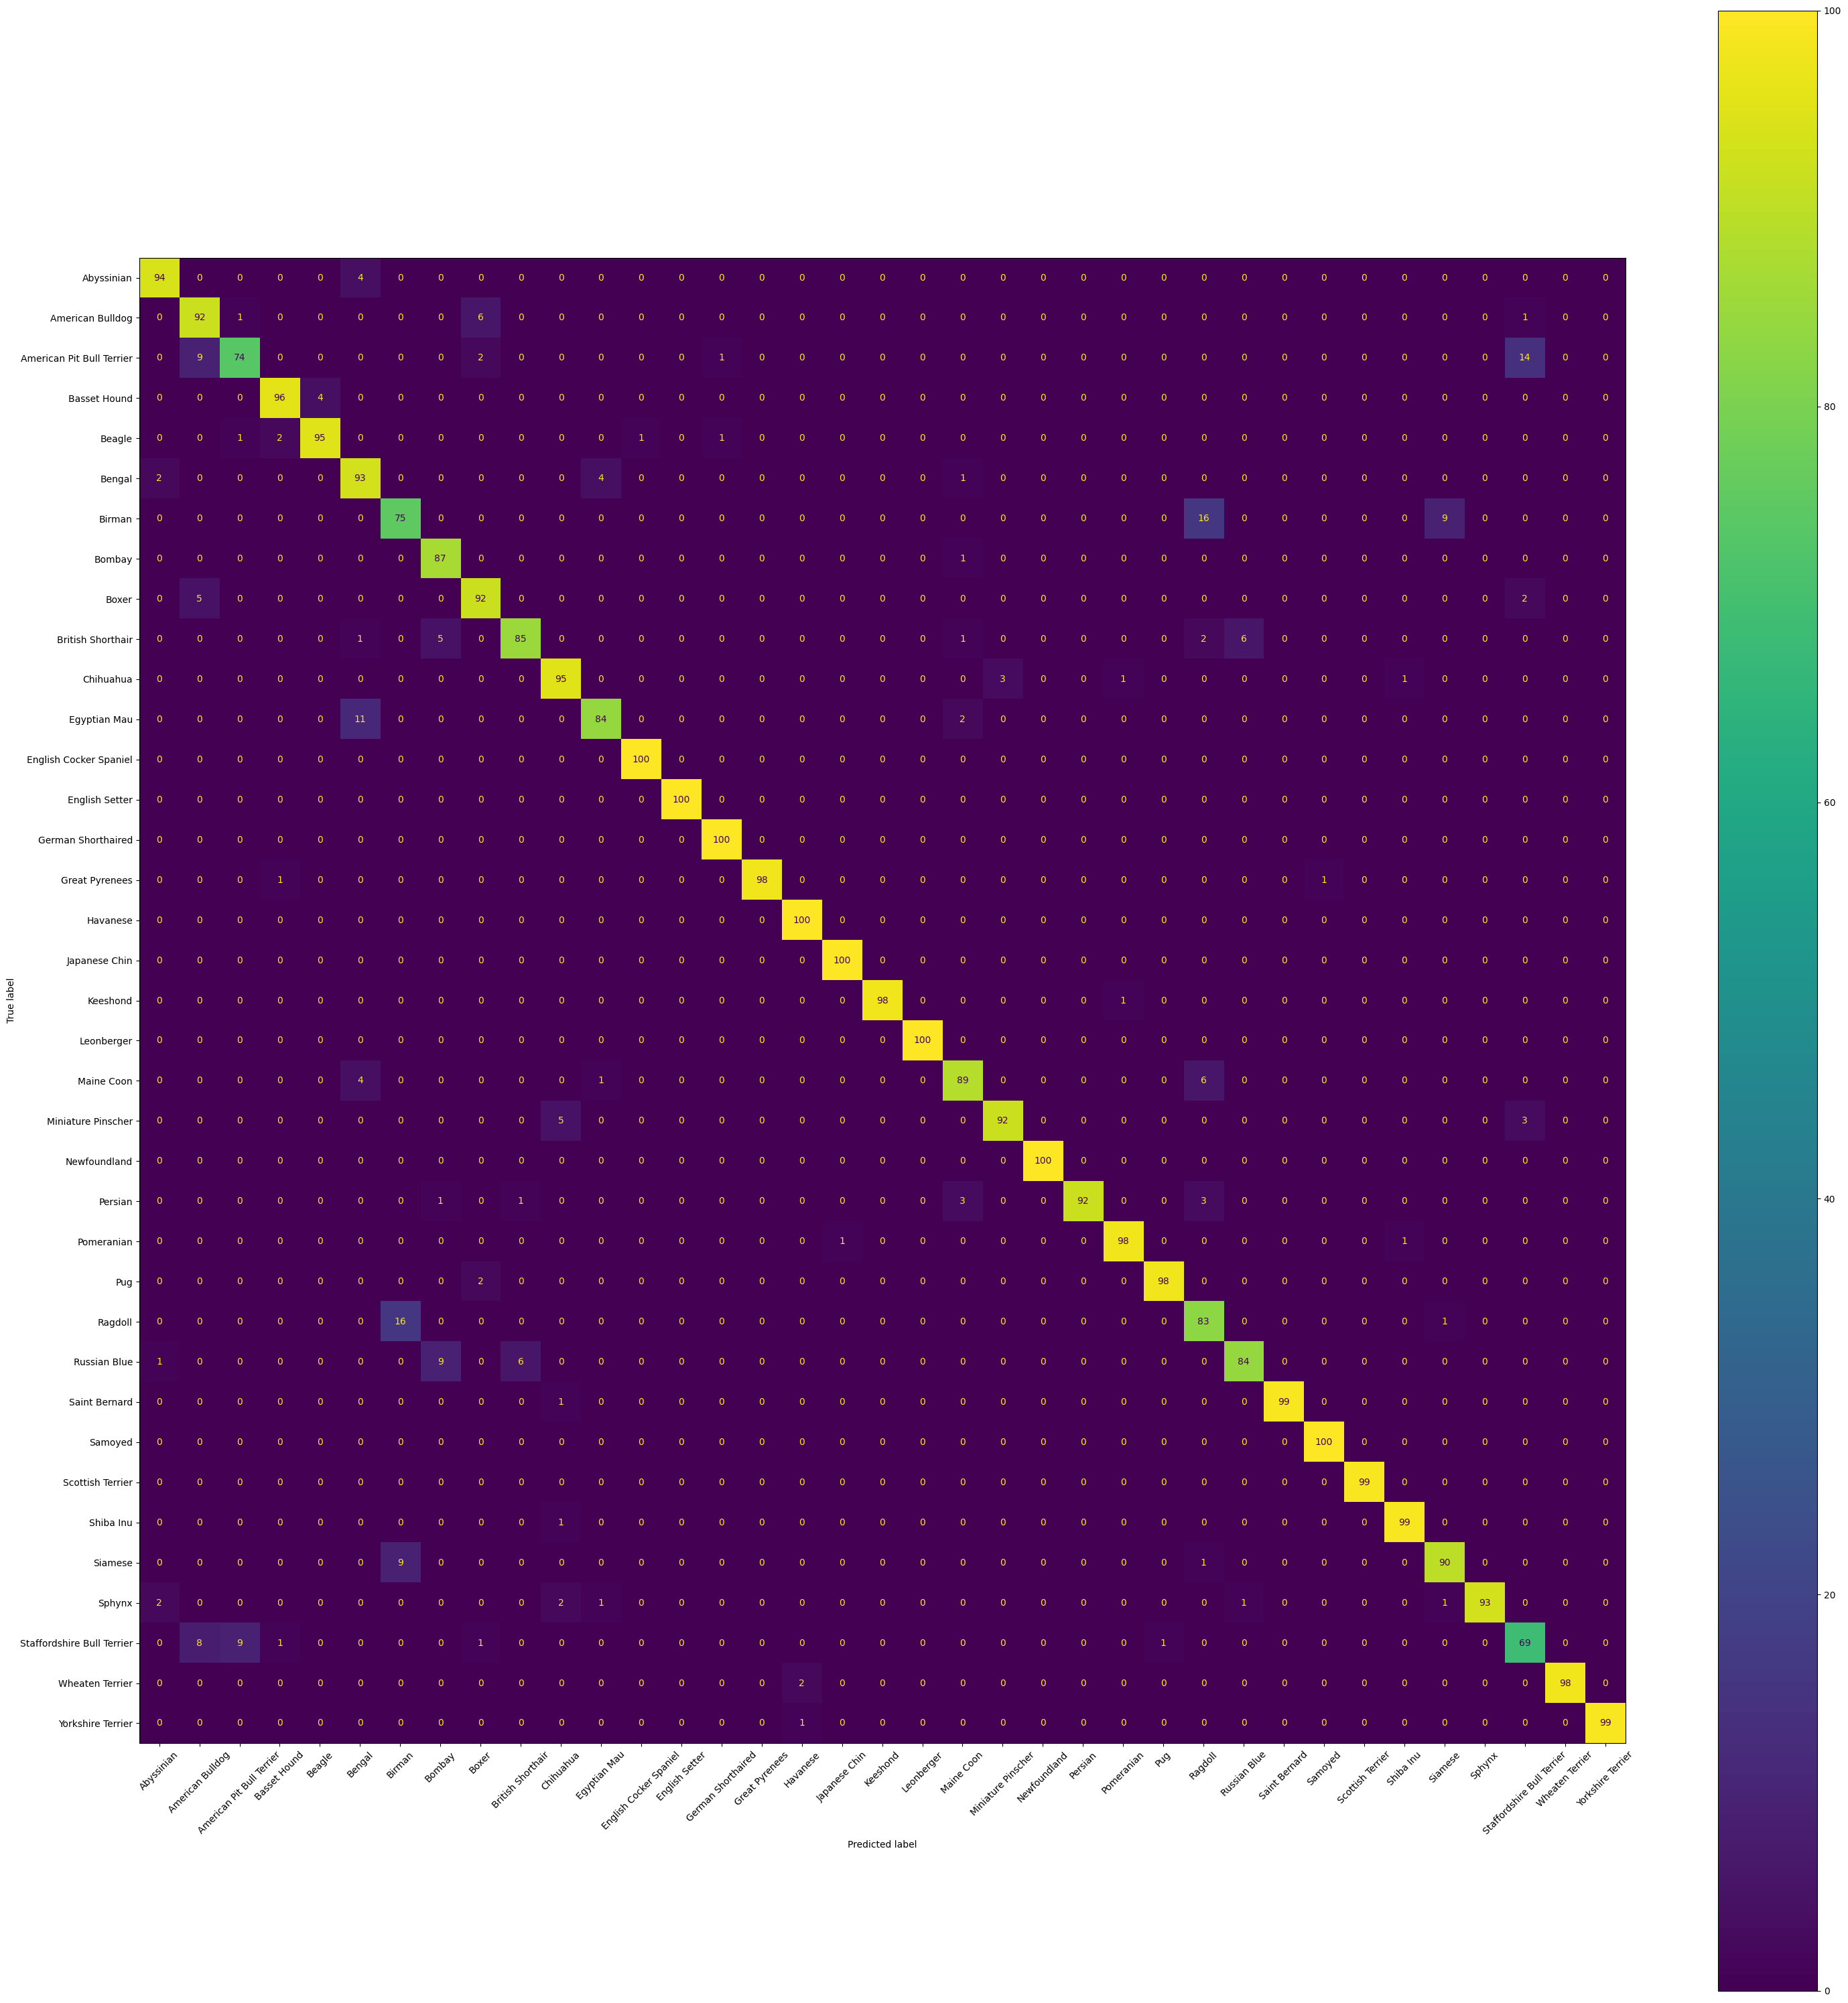

In [ ]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(pixel_values=imgs).logits
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = labels.cpu().numpy()
        all_labels.extend(labels.tolist())
        all_preds.extend(preds.tolist())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# torch.save(model.state_dict(), "vit_finetuned_final.pth")
# print("Model saved successfully.")

Model saved successfully.


----